In [ ]:
# Import standard libraries
import os  # For file and directory operations
import numpy as np  # For numerical computations and array handling

# Import TensorFlow and Keras
import tensorflow as tf  # Main deep learning framework

# For plotting and visualization (e.g., displaying images or loss curves)
import matplotlib.pyplot as plt

# Import components from Keras to build custom models
from tensorflow.keras.models import Model  # Base class for model creation using Functional API

# Layers for CNN-based architectures
from tensorflow.keras.layers import (
    Input,             # Defines input shape for the model
    Conv2D,            # 2D convolutional layer for feature extraction
    BatchNormalization,  # Normalizes inputs to stabilize and speed up training
    Activation,        # Applies activation functions like ReLU, sigmoid
    UpSampling2D,      # Upsamples feature maps (typically in decoder part of segmentation models)
    Add,               # Element-wise addition (used in residual connections)
    Concatenate,       # Concatenates feature maps (e.g., skip connections in U-Net)
    Lambda             # For applying arbitrary TensorFlow functions (e.g., custom tensor ops)
)

# Optimizer for training the model
from tensorflow.keras.optimizers import Adam  # Common optimizer for CNNs and segmentation tasks

# Backend for custom operations (e.g., custom loss functions)
from tensorflow.keras import backend as K

# Utilities for image loading and preprocessing
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # Load and convert images to arrays

# Custom data generator support
from tensorflow.keras.utils import Sequence  # Base class for building efficient data loaders

# Load saved Keras models (e.g., pre-trained or previously trained models)
from tensorflow.keras.models import load_model

# Utility for splitting dataset into training and validation/test sets
from sklearn.model_selection import train_test_split

# Glob module to match file paths using patterns (e.g., '*.png' to get all PNG files)
from glob import glob

# OpenCV for advanced image processing (resizing, reading, augmenting images)
import cv2


In [ ]:
# Define the LEGNet Edge Guidance Block (LEG Block)
def leg_block(input_tensor, out_channels):
    # Local feature extraction using a standard 3x3 convolution
    # This helps extract spatial details from the input feature map
    local = Conv2D(out_channels, kernel_size=3, padding='same')(input_tensor)
    local = BatchNormalization()(local)             # Normalizes the output to stabilize and accelerate training
    local = Activation('relu')(local)               # Applies ReLU activation for non-linearity

    # Edge guidance path: focuses on edge-aware features using dilated convolution (similar to applying a Sobel-like edge detector)
    # Dilation enlarges the receptive field without reducing resolution, helping to capture broader contextual edge info
    edge_guidance = Conv2D(out_channels, kernel_size=3, padding='same', dilation_rate=2)(input_tensor)
    edge_guidance = BatchNormalization()(edge_guidance)  # Normalizes the edge features
    edge_guidance = Activation('relu')(edge_guidance)    # Applies ReLU activation

    # Fuse local and edge-aware features by element-wise addition
    fused = Add()([local, edge_guidance])

    # Final ReLU activation after fusion to introduce non-linearity to the combined output
    return Activation('relu')(fused)


In [ ]:
# LEGNet Model Architecture
def LEGNet(input_shape):
    inputs = Input(shape=input_shape)  # Define the input tensor with the specified shape

    # First LEG block: captures fine-grained local and edge-aware features
    x = leg_block(inputs, 64)
    x = leg_block(x, 64)
    skip = x  # Store output for a skip connection to be reused later (helps retain high-res info)

    # Downsampling: reduce spatial dimensions while increasing feature channels
    x = Conv2D(128, kernel_size=3, strides=2, padding='same')(x)  # Strided conv for downsampling
    x = BatchNormalization()(x)  # Normalize activations
    x = Activation('relu')(x)    # Apply non-linearity

    # LEG block after downsampling: extract mid-level features at lower resolution
    x = leg_block(x, 128)

    # Process the skip connection to match current resolution and channels
    skip = Conv2D(128, kernel_size=3, strides=2, padding='same')(skip)  # Downsample skip
    skip = BatchNormalization()(skip)
    skip = Activation('relu')(skip)

    # Feature fusion: concatenate skip connection with current features
    x = Concatenate()([x, skip])  # Channel-wise concatenation for richer representation

    # LEG block and convolution to refine the fused features
    x = leg_block(x, 64)
    x = Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)  # Further processing

    # Upsampling: restore spatial dimensions using bilinear interpolation
    x = UpSampling2D(size=(2, 2), interpolation='bilinear')(x)

    # Final output layer: produce single-channel binary mask using sigmoid
    x = Conv2D(1, kernel_size=1, activation='sigmoid')(x)

    # Build the model using Keras Functional API
    model = Model(inputs=inputs, outputs=x)
    return model


In [ ]:
# Define Dice Loss (commonly used for segmentation tasks)
def dice_loss(y_true, y_pred, smooth=1e-6):
    # Flatten the ground truth and predicted masks into 1D vectors
    y_true_f = K.flatten(y_true)  # Flattens y_true to a 1D tensor
    y_pred_f = K.flatten(y_pred)  # Flattens y_pred to a 1D tensor

    # Compute the intersection between true and predicted pixels (overlap)
    intersection = K.sum(y_true_f * y_pred_f)

    # Compute Dice coefficient with smoothing to avoid division by zero
    # Dice = (2 * intersection) / (sum of all true and predicted pixels)
    # Dice Loss = 1 - Dice Coefficient
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [ ]:
# Define Dice Coefficient metric (used to measure overlap between predicted and true masks)
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    # Flatten the true and predicted masks into 1D tensors
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Ensure both tensors are of type float32 to avoid type mismatches
    y_true_f = K.cast(y_true_f, dtype='float32')
    y_pred_f = K.cast(y_pred_f, dtype='float32')

    # Compute the intersection between prediction and ground truth
    intersection = K.sum(y_true_f * y_pred_f)

    # Compute the Dice coefficient with smoothing to prevent division by zero
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [ ]:
# PNG Data Generator for image-mask pairs (used in segmentation tasks)
class PNGDataGenerator(Sequence):  # Inherits from Keras Sequence for multi-processing and safety
    def __init__(self, image_dir, mask_dir=None, batch_size=8, img_size=(128, 128), shuffle=True):
        self.image_dir = image_dir      # Directory containing input images
        self.mask_dir = mask_dir        # Directory containing corresponding masks (optional for inference)
        self.batch_size = batch_size    # Number of samples per batch
        self.img_size = img_size        # Target size of each image (width, height)
        self.shuffle = shuffle          # Whether to shuffle data after each epoch
        self.image_files = sorted(os.listdir(image_dir))  # Sorted list of image filenames
        self.mask_files = sorted(os.listdir(mask_dir)) if mask_dir else None  # Sorted list of mask filenames (if provided)
        self.on_epoch_end()            # Initialize index array (optionally shuffled)

    def __len__(self):
        # Returns number of batches per epoch
        return int(np.floor(len(self.image_files) / self.batch_size))

    def on_epoch_end(self):
        # Updates indices after each epoch and optionally shuffles them
        self.indices = np.arange(len(self.image_files))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        # Generate one batch of data using the given index
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]  # Get current batch indices
        batch_images = [self.image_files[k] for k in indices]  # Load batch image filenames

        images = []  # List to store loaded and processed images
        masks = []   # List to store corresponding masks

        for i, img_file in enumerate(batch_images):
            # Load and preprocess the image
            img = load_img(os.path.join(self.image_dir, img_file), target_size=self.img_size)  # Resize image
            img = img_to_array(img) / 255.0  # Convert to array and normalize to [0, 1]
            images.append(img)

            # Load and preprocess the corresponding mask if available
            if self.mask_dir and img_file in self.mask_files:
                mask = load_img(os.path.join(self.mask_dir, img_file), target_size=self.img_size, color_mode="grayscale")  # Load as grayscale
                mask = img_to_array(mask) / 255.0  # Normalize mask
                masks.append(mask)
            else:
                # If mask not found (e.g., during inference), use a dummy zero mask
                masks.append(np.zeros((*self.img_size, 1)))

        # Return numpy arrays of images and masks as a batch
        return np.array(images), np.array(masks)


In [ ]:
# Define the input shape for the model (height, width, channels)
input_shape = (128, 128, 3)  # Typical RGB image input

# Paths to training images and corresponding masks (segmentation labels)
image_dir = '/content/drive/MyDrive/data /landdata/landslide/image'  # Directory of input images
mask_dir = '/content/drive/MyDrive/data /landdata/landslide/mask'    # Directory of corresponding masks

# Create an instance of the PNGDataGenerator to load data in batches
train_gen = PNGDataGenerator(
    image_dir=image_dir,
    mask_dir=mask_dir,
    batch_size=10              # Number of image-mask pairs per batch
)

# Initialize the LEGNet model with the specified input shape
model = LEGNet(input_shape)

# Compile the model:
# - Adam optimizer with learning rate 1e-4
# - dice_loss: loss function suited for segmentation
# - accuracy and dice_coefficient as evaluation metrics
model.compile(
    optimizer=Adam(1e-4),
    loss=dice_loss,
    metrics=['accuracy', dice_coefficient]
)

# Display the model architecture and number of parameters
model.summary()

# Train the model using the data generator
model.fit(
    train_gen,      # Training data
    epochs=50       # Number of full training passes over the dataset
)

# Save the trained model to disk for later inference or evaluation
model.save("/content/drive/MyDrive/data /landdata/landslide/legnet_landslide.h5")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_30       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_31       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 128, 128,  │          0 │ activation_30[0]… │
│                     │ 64)               │            │ activation_31[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 128, 128,  │          0 │ add_4[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_32[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_32[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 128, 128,  │          0 │ activation_33[0]… │
│                     │ 64)               │            │ activation_34[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 128, 128,  │          0 │ add_5[0][0]     

 Total params: 855,937 (3.27 MB)

 Trainable params: 854,145 (3.26 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.9521 - dice_coefficient: 0.2019 - loss: 0.7981
Epoch 2/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 43s 94ms/step - accuracy: 0.9699 - dice_coefficient: 0.3099 - loss: 0.6901
Epoch 3/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accuracy: 0.9676 - dice_coefficient: 0.2596 - loss: 0.7404
Epoch 4/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.9710 - dice_coefficient: 0.2915 - loss: 0.7085
Epoch 5/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.9714 - dice_coefficient: 0.3201 - loss: 0.6799
Epoch 6/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.9757 - dice_coefficient: 0.3126 - loss: 0.6874
Epoch 7/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 84s 96ms/step - accuracy: 0.9754 - dice_coefficient: 0.3397 - loss: 0.6603
Epoch 8/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.9780 - dice_coefficient: 0.3553 - loss: 0.6447
Epoch 9/50
455/455 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - accuracy: 0.9762 - dice_c

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Processed ddfgf10157.png with avg confidence: 0.1280
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Processed ddfgf10158.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Processed ddfgf10159.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Processed ddfgf10160.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Processed ddfgf10161.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Processed ddfgf10162.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Processed ddfgf10163.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Processed ddfgf10164.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Processed ddfgf10165.png with avg confidence: 0.0006
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Processed ddfgf10166.png with avg confidence: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Processed ddfgf10167.png with avg confidence: 0.0095
1

Testing on 1209 images...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

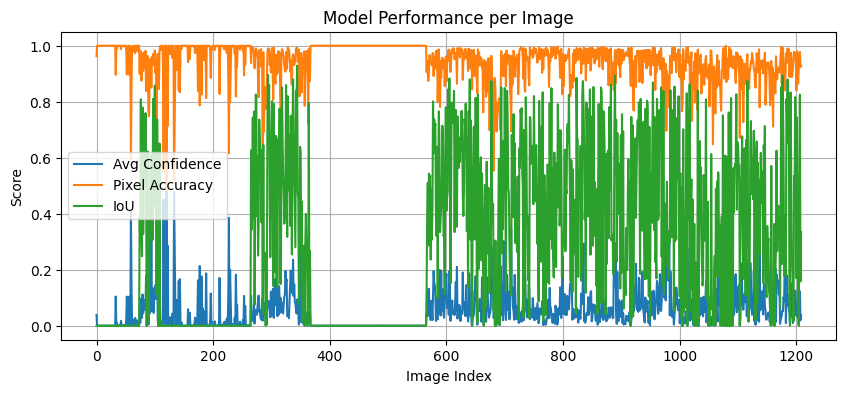

In [ ]:
# Import required libraries
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# Load the trained LWGANet (LEGNet) model for landslide segmentation
model_path = "/content/drive/MyDrive/data/legnet_landslide_segmentation.h5"
model = load_model(model_path, compile=False)  # Skip compile since we're only doing inference

# Define the test image and mask directories
test_dir = "/content/drive/MyDrive/data /land test/images"     # Directory containing test images
mask_dir = "/content/drive/MyDrive/data /land test/Masks"      # Directory containing ground truth masks
output_dir = "/content/drive/MyDrive/data/resultsLWANet"       # Directory to save prediction visualizations
os.makedirs(output_dir, exist_ok=True)                         # Create output directory if it doesn't exist

# Load all image file paths (assuming PNG format)
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))

# Define the input size for the model (must match training resolution)
img_size = (128, 128)

# Define the function to make predictions and visualize the results
def predict_and_visualize(image_paths, model, img_size, max_images=50):
    print(f"Testing on {len(image_paths)} images...\n")
    avg_confidences = []  # List to hold average prediction confidence per image
    all_accuracies = []   # List to hold pixel-wise accuracy per image
    all_ious = []         # List to hold IoU score per image

    # Loop through each test image up to the max_images limit
    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, img_name)  # Corresponding ground truth mask

        # Load and preprocess the test image
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img) / 255.0                    # Normalize to [0, 1]
        input_tensor = np.expand_dims(img_array, axis=0)         # Add batch dimension (1, H, W, C)

        # Load and preprocess ground truth mask (if exists)
        if os.path.exists(mask_path):
            mask = load_img(mask_path, target_size=img_size, color_mode='grayscale')
            mask_array = img_to_array(mask).squeeze() / 255.0     # Normalize and remove channel axis
            bin_mask = (mask_array > 0.5).astype(np.uint8)        # Binarize the ground truth mask
        else:
            bin_mask = np.zeros(img_size, dtype=np.uint8)         # Use empty mask if not available

        # Perform prediction using the model
        pred = model.predict(input_tensor)[0, :, :, 0]            # Get the prediction map (no batch, no channel)
        bin_pred = (pred > 0.5).astype(np.uint8)                  # Convert to binary mask (threshold 0.5)
        avg_confidence = np.mean(pred)                            # Mean confidence of the prediction
        avg_confidences.append(avg_confidence)

        # Compute pixel-wise accuracy
        pixel_accuracy = np.mean(bin_pred == bin_mask)
        all_accuracies.append(pixel_accuracy)

        # Compute Intersection over Union (IoU)
        intersection = np.logical_and(bin_pred, bin_mask).sum()
        union = np.logical_or(bin_pred, bin_mask).sum()
        iou = intersection / union if union != 0 else 0
        all_ious.append(iou)

        # Draw contours on the original image for visualization
        img_cv = (img_array * 255).astype(np.uint8)               # Convert normalized image back to [0, 255]
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)          # Convert RGB to BGR for OpenCV compatibility
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(img_cv, contours, -1, (0, 0, 255), 1)    # Draw red contours

        # Create a multi-view plot for each prediction
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        fig.suptitle(f"{img_name} - Conf: {avg_confidence:.3f} - Acc: {pixel_accuracy:.3f} - IoU: {iou:.3f}", fontsize=12)

        axes[0].imshow(img_array)                  # Show original image
        axes[0].set_title("Original")
        axes[0].axis('off')

        axes[1].imshow(pred, cmap='jet')           # Show prediction heatmap
        axes[1].set_title("Raw Prediction")
        axes[1].axis('off')

        axes[2].imshow(bin_pred, cmap='gray')      # Show binary prediction
        axes[2].set_title("Predicted Mask")
        axes[2].axis('off')

        axes[3].imshow(bin_mask, cmap='gray')      # Show ground truth mask
        axes[3].set_title("Ground Truth Mask")
        axes[3].axis('off')

        axes[4].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))  # Show contour overlay
        axes[4].set_title("Contours")
        axes[4].axis('off')

        # Save the visualization plot to disk
        plt.tight_layout()
        result_path = os.path.join(output_dir, f"result_{idx:03d}_{img_name}")
        plt.savefig(result_path)
        plt.close()

    # Plot a summary graph showing confidence, accuracy, and IoU per image
    plt.figure(figsize=(10, 4))
    plt.plot(avg_confidences, label='Avg Confidence')
    plt.plot(all_accuracies, label='Pixel Accuracy')
    plt.plot(all_ious, label='IoU')
    plt.xlabel("Image Index")
    plt.ylabel("Score")
    plt.title("Model Performance per Image")
    plt.legend()
    plt.grid(True)
    graph_path = os.path.join(output_dir, "metrics_plot.png")
    plt.savefig(graph_path)
    plt.show()

# Run the evaluation on test images and save visualizations
predict_and_visualize(image_paths, model, img_size, max_images=1600)


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# Define paths for model, test images, and masks
model_path = "/content/drive/MyDrive/data/legnet_landslide_segmentation.h5"  # Trained LWGANet model
test_dir = "/content/drive/MyDrive/data /land test/images"             # Directory with test RGB images
mask_dir = "/content/drive/MyDrive/data /land test/Masks"              # Ground truth masks (not used here, but passed)
output_dir = "/content/drive/MyDrive/data/land test/resultsLWANet1"   # Save visual results
infrared_dir = "/content/drive/MyDrive/data /land test/Infrared"      # Optional infrared images

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load the trained model
model = load_model(model_path, compile=False)

# Load image paths
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))
img_size = (128, 128)  # Image resize dimensions

# Prediction and visualization function
def predict_and_visualize_combined(image_paths, model, img_size, max_images=50):
    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, img_name)
        ir_path = os.path.join(infrared_dir, img_name) if os.path.exists(infrared_dir) else None

        # Load RGB image and preprocess
        rgb_img = load_img(img_path, target_size=img_size)
        rgb_array = img_to_array(rgb_img) / 255.0
        input_tensor = np.expand_dims(rgb_array, axis=0)

        # Load infrared image if available
        ir_array = None
        if ir_path and os.path.exists(ir_path):
            ir_img = load_img(ir_path, target_size=img_size, color_mode='grayscale')
            ir_array = img_to_array(ir_img).squeeze() / 255.0  # Normalize grayscale

        # Load ground truth mask and binarize
        bin_mask = np.zeros(img_size, dtype=np.uint8)
        if os.path.exists(mask_path):
            gt_mask = load_img(mask_path, target_size=img_size, color_mode='grayscale')
            gt_array = img_to_array(gt_mask).squeeze() / 255.0
            bin_mask = (gt_array > 0.5).astype(np.uint8)

        # Predict segmentation mask using LWGANet
        pred = model.predict(input_tensor)[0, :, :, 0]
        bin_pred = (pred > 0.5).astype(np.uint8)        # Threshold prediction
        avg_conf = np.mean(pred)                        # Average prediction confidence

        # Prepare visualization image (draw contours and bounding boxes)
        vis_img = (rgb_array * 255).astype(np.uint8)
        vis_img = cv2.cvtColor(vis_img, cv2.COLOR_RGB2BGR)
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw bounding boxes and contour lines for detected landslide areas
        for cnt in contours:
            if cv2.contourArea(cnt) > 10:
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.drawContours(vis_img, [cnt], -1, (0, 0, 255), 1)      # Red contour
                cv2.rectangle(vis_img, (x, y), (x+w, y+h), (255, 0, 0), 1) # Blue box
                cv2.putText(vis_img, "Landslide Path", (x, y-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 1)  # Yellow label

        # Prepare visualization layout (with or without infrared)
        num_cols = 6 if ir_array is not None else 5
        fig, axes = plt.subplots(1, num_cols, figsize=(22, 4))
        fig.suptitle(f"{img_name} | Confidence: {avg_conf:.3f}", fontsize=14)

        # Display original RGB image
        axes[0].imshow(rgb_array)
        axes[0].set_title("RGB Image")
        axes[0].axis("off")

        # Display infrared image if present
        if ir_array is not None:
            axes[1].imshow(ir_array, cmap="hot")
            axes[1].set_title("Infrared Image")
            axes[1].axis("off")
            start_idx = 2
        else:
            start_idx = 1

        # Display binary prediction mask
        axes[start_idx+1].imshow(bin_pred, cmap="gray")
        axes[start_idx+1].set_title("Predicted Mask")
        axes[start_idx+1].axis("off")

        # Display ground truth mask
        axes[start_idx+2].imshow(bin_mask, cmap="gray")
        axes[start_idx+2].set_title("Ground Truth Mask")
        axes[start_idx+2].axis("off")

        # Save combined figure to disk
        plt.tight_layout()
        result_path = os.path.join(output_dir, f"combined_{idx:03d}_{img_name}")
        plt.savefig(result_path)
        plt.close()

# Execute the function for up to 1600 test images
predict_and_visualize_combined(image_paths, model, img_size, max_images=1600)


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# === Paths ===
model_path = "/content/drive/MyDrive/data/legnet_landslide_segmentation.h5"  # Trained LWGANet model
test_dir = "/content/drive/MyDrive/data /land test/images"             # Directory with test RGB images
mask_dir = "/content/drive/MyDrive/data /land test/Masks"              # Ground truth masks (not used here, but passed)


# === Load the trained model ===
model = load_model(model_path, compile=False)

# === Load image paths from the test image directory ===
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))
img_size = (128, 128)  # Resize all images to this dimension before prediction

# === Batch processing function ===
def analyze_landslide_presence_batch(image_paths, model, img_size, mask_dir, infrared_dir=None, max_images=50, batch_size=32):
    landslide_count = 0
    no_landslide_count = 0

    print(f"Processing {min(len(image_paths), max_images)} images...\n")

    # Process images in batches
    for idx in range(0, min(len(image_paths), max_images), batch_size):
        batch_paths = image_paths[idx:idx + batch_size]
        batch_images = []

        # Load and preprocess batch of images
        for img_path in batch_paths:
            rgb_img = load_img(img_path, target_size=img_size)
            rgb_array = img_to_array(rgb_img) / 255.0  # Normalize to [0, 1]
            batch_images.append(rgb_array)

        batch_images = np.array(batch_images)

        # Predict segmentation masks for the batch
        preds = model.predict(batch_images, verbose=0)

        # Analyze each image in the batch
        for pred in preds:
            bin_pred = (pred > 0.5).astype(np.uint8)  # Threshold prediction
            contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            has_landslide = any(cv2.contourArea(cnt) > 10 for cnt in contours)

            if has_landslide:
                landslide_count += 1
            else:
                no_landslide_count += 1

    # Summary
    total_images = min(len(image_paths), max_images)
    summary_text = f"Total Images Processed: {total_images}\n" \
                   f"Landslide Detected: {landslide_count}\n" \
                   f"No Landslide Detected: {no_landslide_count}\n"
    print(summary_text)

# === Run batch analysis on up to 1600 test images ===
analyze_landslide_presence_batch(
    image_paths=image_paths,
    model=model,
    img_size=img_size,
    mask_dir=mask_dir,
    infrared_dir=infrared_dir,
    max_images=1600
)

Processing 1209 images...

Total Images Processed: 1209
Landslide Detected: 842
No Landslide Detected: 367

